In [1]:
import aeon
from aeon.datasets import load_classification
import numpy as np
from sklearn.metrics import balanced_accuracy_score
import dtw as DTW_package #Name of package is actually dtw-python
from aeon.datasets.dataset_collections import get_available_tsc_datasets
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import random


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
import sys
sys.path.append('../')
import pytranskit.OneNN_divergences as NN

# Classification function

In [3]:
def classify(training_samples, test_data, distance):
    """
    1 nearest neighbours algorithm using the distance or divergence provided. 
    Inputs:
        training_samples: array of labeled data, each row is a signal with label in the first column.
        test_data: array of labeled data, each row is a signal with label in the first column.
        distance: function that computes a dissimilarity or distance between two signals (one dimensional arrays).
    Output: 
        Balanced accuracy of 1nn with selected distance or divergence
    """
    training_samples_labels = training_samples[:, 0]
    test_data_labels = test_data[:, 0]
    train = training_samples[:, 1:]
    test = test_data[:, 1:]
    distances = np.zeros([len(train), len(test)])
    for i in range(len(train)):
        for j in range(len(test)):
            # print(dtw(signal1[j],signal2[i]).distance)
            distances[i, j] = distance(test[j], train[i])

    labels_out = training_samples_labels[np.argmin(distances, axis=0)]
    return balanced_accuracy_score(labels_out, test_data_labels) * 100

# Classification of synthetic dataset example

1) We create a synthetic dataset with 4 classes, 50 samples per class, and randonly generated templates using the function NN.synthetic_dataset_builder. This creates a dataset of signals where each class is is built starting with a random template $\phi^{(i)}$ and random deformations $g\in \mathcal{G}$ that are non-decreasing functions $g:[0,1] \to [0,1].$ The signals of class $(i)$ are of the form 
$$
    s = \phi^{(i)} \circ g, \text{ with } g\in\mathcal{G}
$$
The dataset is formated as an array of size Nx(M+1) where N is the number of total samples, M is the lenght of each signal and the first column of the array represents the label of the corresponding row.

3) We plot 3 samples of each class using the function NN.print_samples.
4) We split the dataset into training and testing. Training set has 2 samples per class.
5) We classify using 1 nearest neighbours with dtw and d_T divergences and report accuracies.

dtw accuracy: 100.0
d_T accuracy: 100.0


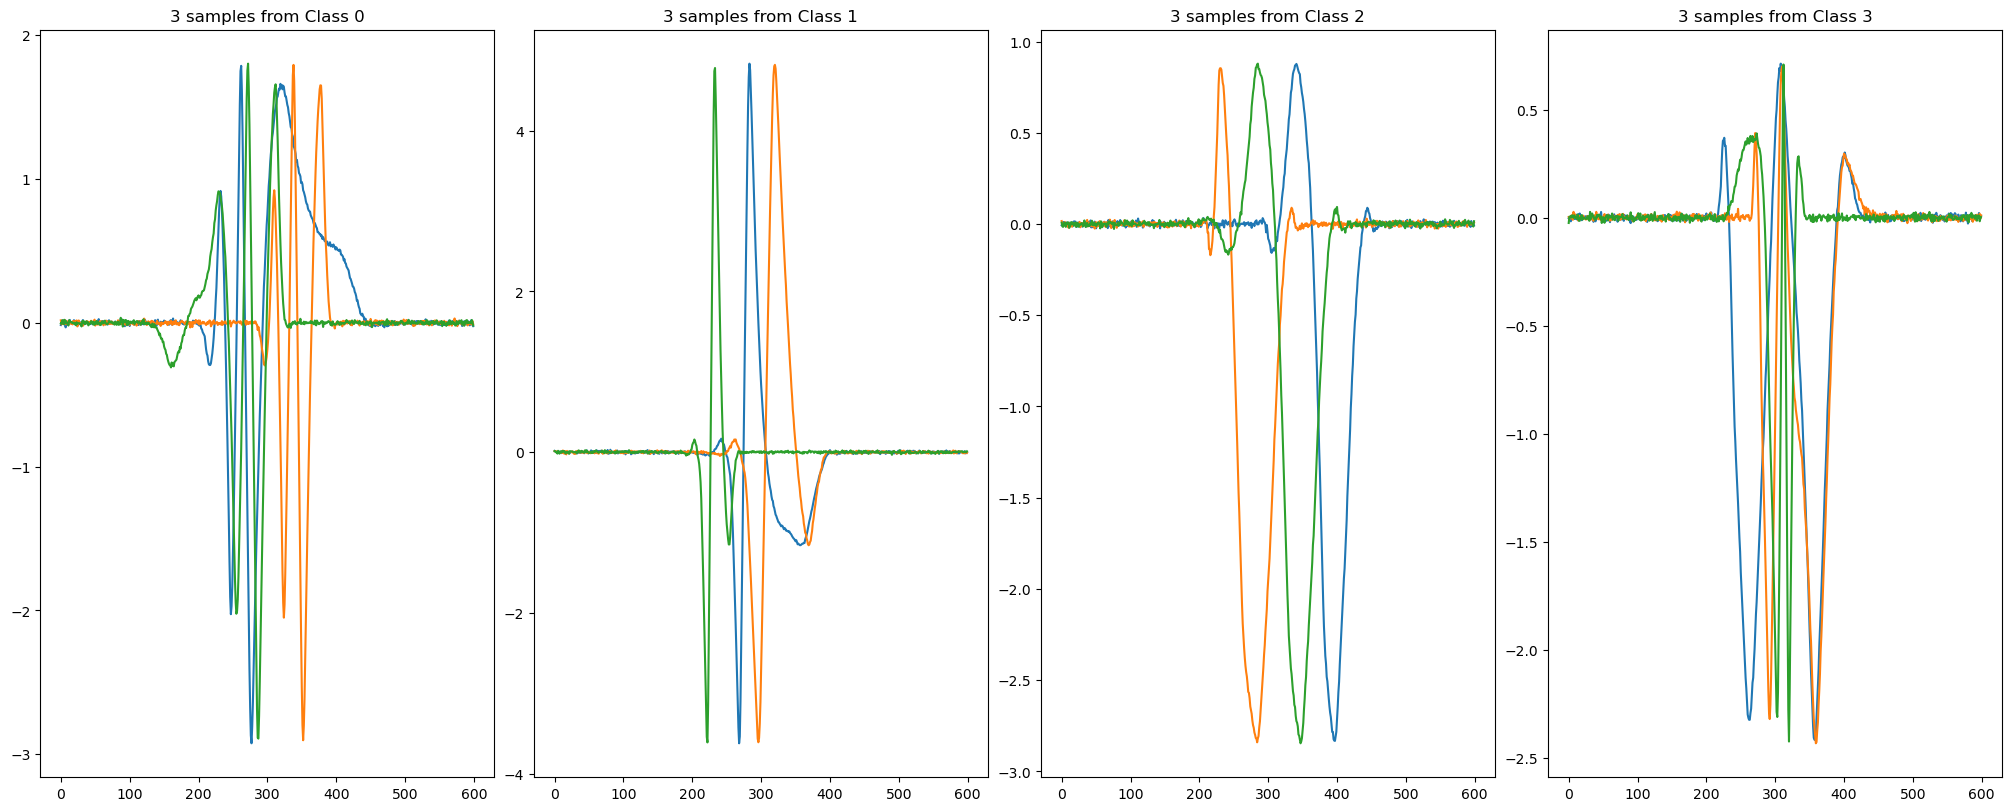

In [4]:
dataset = NN.synthetic_dataset_builder(num_classes= 4,num_samples_per_class = 50, noise_level = 0.01, create_template = True)
NN.print_samples(dataset, 3)
train_data, test_data = NN.select_samples(dataset,2)

for method in [NN.dtw,NN.d_T]:
    accuracy = classify(train_data, test_data, method)
    print(f'{method.__name__} accuracy: {accuracy}')

# Classification of datasets from timeseriesclassification.com examples

In this section we run the same classification algorithm as before but for real-world datasets from the timer series classification repository (TSC). 
1) The first cell is an auxiliary function to get the datasets from TSC in the correct format.
2) In the second cell the user can choose which dataset and divergence to use.
3) The third cell loads train and test splits, runs 1NN with the chosen divergence, and reports classification accuracy.

In [5]:
def load_from_aeon(dataset):
    '''
    Loads and zero-means datasets from timeseriesclassification.com. Returns train and test separatedly.
    Train and test are matrices where the first column represents the label.
    
    Input:
        dataset: name of dataset as in timeseriesclassification.com
    Outputs:
        Train and test splits from selected dataset with labels in first column
    '''
    XX_train, yy_train = load_classification(dataset, split="train")
    XX_train = XX_train.reshape(XX_train.shape[0], XX_train.shape[-1])
    XX_train = XX_train.astype(np.float64)
    yy_train = yy_train.astype(np.float64)

    XX_test, yy_test = load_classification(dataset, split="test")
    XX_test = XX_test.reshape(XX_test.shape[0], XX_test.shape[-1])
    XX_test = XX_test.astype(np.float64)
    yy_test = yy_test.astype(np.float64)

    ZZ_train = np.hstack([yy_train.reshape(-1,1), XX_train])
    ZZ_test = np.hstack([yy_test.reshape(-1,1), XX_test])

    return ZZ_train, ZZ_test

In [6]:
selected_dataset_name = 'BME'
selected_method = NN.d_T

# For a list of possible datasets print(get_available_tsc_datasets())
# Methods can be NN.d_T or NN.dtw

In [7]:
train_data, test_data = load_from_aeon(selected_dataset_name)
accuracy = classify(train_data, test_data, selected_method)

print(f'Divergence: {selected_method.__name__}')
print(f'Dataset: {selected_dataset_name}')
print(f'Accuracy: {accuracy}')

Divergence: d_T
Dataset: BME
Accuracy: 98.71794871794873
